# Time-domain: Scattering From a Conducting Sphere

This extends the dipole notebook by placing a conducting sphere in the radiated
field. The dipole is offset from the centre, the sphere sits $50\;\text{mm}$ away
from it, and what the snapshots show is the incident wave meeting the obstacle and
scattering off it.

The scheme is the same leapfrog as before, with one addition: the electric update
must now cope with a conducting region. Adding an ohmic term to Ampère's law,

$$\mathbf{M}_\varepsilon \frac{d\hat{e}}{dt} + \mathbf{M}_\sigma \hat{e}
= \tilde{\mathbf{C}}\hat{h} - \hat{\hat{\jmath}}$$

looks harmless but is not, because the ratio $\sigma/\varepsilon$ in copper is of
order $10^{18}\;\text{s}^{-1}$ while the time step is around $4\;\text{ps}$. The
product $\sigma\Delta t/\varepsilon$ is then astronomically large, and the usual
semi-implicit treatment of the loss term breaks down completely. The loop below
integrates the term exactly instead, which stays stable at any conductivity.

**The scattering regime is worth naming before looking at the results.** At
$10\;\text{GHz}$ the wavelength is $30\;\text{mm}$, and the sphere has a radius of
$20\;\text{mm}$ — so $ka \approx 4.2$, with the diameter about $1.3$ wavelengths.
That is the resonance region: too large for Rayleigh scattering, too small for a
geometric-optics shadow. Expect a strong forward lobe, a genuine shadow behind the
sphere, and interference structure in front of it where the incident and scattered
waves overlap.

**The sphere is not resolved as a conductor.** At this frequency the skin depth in
copper is $0.66\;\mu\text{m}$, against a cell size of $2\;\text{mm}$ — four orders
of magnitude smaller. The grid cannot represent the field decay inside the metal at
all. What it does represent is a body whose surface field is driven essentially to
zero within one cell, which is the correct behaviour for a scatterer at this
frequency: the sphere acts as a perfect conductor, and the interior physics is
irrelevant to the scattered field. This is worth being explicit about, since a
result that looks right for the wrong reason is easy to over-trust.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."); io = devnull)
Pkg.develop(path = joinpath(@__DIR__, "..", ".."); io = devnull)
using FITToolbox;
using Statistics
using LinearAlgebra
using CairoMakie
CairoMakie.activate!(type = "png", px_per_unit = 1)
using IterativeSolvers
using SparseArrays

function get_tangential_boundary(config::FITDomain)
    diag_vec = ones(Float64, 3*config.Np)
    # zero out the tangential entries; the rest pass through unchanged
    diag_vec[get_all_tangential_boundary_indices(config)] .= 0.0
    return spdiagm(0 => diag_vec)
end

get_tangential_boundary (generic function with 1 method)

## Domain, sphere and dipole

A $200 \times 200 \times 200\;\text{mm}$ vacuum domain at $2\;\text{mm}$
resolution, as before.

The sphere is placed first, at $x = 130\;\text{mm}$ with a radius of
$20\;\text{mm}$, so it spans $110$ to $150\;\text{mm}$ along the axis. It fills
roughly $4200$ cells. `create_sphere!` decides cell by cell using a $3\times3\times3$
sub-sampling and a fifty-percent rule, which gives a smoother staircase
approximation of the surface than a simple centre test — at $2\;\text{mm}$ cells
against a $20\;\text{mm}$ radius that matters, since the surface is only ten cells
from the centre.

The dipole sits at $x = 80\;\text{mm}$, leaving a gap of $30\;\text{mm}$ to the
near face of the sphere — almost exactly one wavelength. That is close enough for
the sphere to sit in the transition between the near and far field, so the
scattered pattern will not be quite what a plane-wave illumination would produce.

Placing the source takes two steps, as in the previous notebook. Current is a
facet-integrated quantity, so the excitation must sit on a **dual facet**, and
those exist only at discrete positions. `get_index_entity` finds the nearest one
with a $z$-normal and warns if the snap exceeded `atol`; `get_position_of_index`
then reads back where it actually landed, which is the position the plots mark.

Both objects are offset toward $+x$: the dipole is $80\;\text{mm}$ from the near
wall and the sphere only $50\;\text{mm}$ from the far one. With a PEC boundary that
matters — the reflection from the $+x$ wall returns sooner than from the others and
will reach the sphere before the run ends.

In [2]:
MyDomain = create_domain([200,200,200],[2,2,2];units="mm",σ=0,ε_r=1,μ_r=1); 

x_sphere = 130
y_sphere = MyDomain.nodes_v[end] / 2.0 * 1000 #convert to mm
z_sphere = MyDomain.nodes_w[end] / 2.0 * 1000 #convert to mm

create_sphere!(MyDomain, x_sphere, y_sphere, z_sphere, 20; units="mm", σ=5.8e7, ε_r=1.0, μ_r=1.0);

# These are the approximate coordinates where dipole should be placed
# However, the imprinted current lives on the dual facet and the correct
# position is found via function get_index_entity
x_dipole = 80 # mm
y_dipole = MyDomain.nodes_v[end] / 2.0 * 1000 #convert to mm
z_dipole = MyDomain.nodes_w[end] / 2.0 * 1000 #convert to mm

index_dipole = get_index_entity(MyDomain, DualFacet(), DirZ(), x_dipole, y_dipole, z_dipole; units="mm", atol=0.005);

# For plotting, the dipole positions are updated
x_dipole, y_dipole, z_dipole = get_position_of_index(MyDomain, DualFacet(), index_dipole; units="mm");

## Operators and material matrices

Same construction as the dipole notebook, but $\mathbf{M}_\sigma$ is no longer
zero: it now carries the sphere's conductivity, and it is what makes this run a
scattering problem rather than free radiation.

All three material matrices are diagonal, each holding a ratio of dual to primal
geometry scaled by the local material. The averaging matters at the sphere's
surface: an edge lying on the boundary between a conducting and a vacuum cell gets
a conductivity averaged over the four cells around it, so the transition is smeared
over one cell rather than being a step. That is the usual FIT treatment of a
material interface, and it is the reason the staircase approximation of a curved
surface behaves better than the cell count alone would suggest.

The two curls carry no material information at all. $\mathbf{C}$ maps primal edges
to primal facets, $\tilde{\mathbf{C}}$ maps dual edges to dual facets, and both
contain nothing but $\pm 1$. The discrete identities $\mathbf{S}\mathbf{C} = 0$ and
$\mathbf{C}\mathbf{G} = 0$ hold to machine precision on any grid, so charge
conservation in the scheme follows from the operators themselves rather than from
careful discretisation.

The two curl operators are related by $\tilde{\mathbf{C}} = \mathbf{C}^\mathsf{T}$,
so building both is a convenience rather than a necessity.

All the approximation in the method sits in the material matrices — including
everything about how well the sphere is represented. The topology is error-free.

In [3]:
M_ν = get_reluctivity(MyDomain);
M_σ = get_conductivity(MyDomain)
M_ε = get_permittivity(MyDomain)

C = get_curl(MyDomain,Primal());
C̃ = get_curl(MyDomain, Dual());

## Excitation and time step

A sinusoidal current at $10\;\text{GHz}$, driven through the single dual facet
located above. The free-space wavelength is $\lambda = 30\;\text{mm}$, resolved by
fifteen cells on this grid.

That wavelength is what sets the scattering regime. The sphere's diameter is
$40\;\text{mm}$, about $1.3\lambda$, so the obstacle is comparable to the wave
rather than much larger or much smaller than it — the resonance region, where
neither the Rayleigh nor the geometric-optics limit applies and the scattered
pattern has to be computed.

The time step is $99\%$ of the Courant limit,

$$\Delta t \leq \frac{\Delta}{c\sqrt{3}} \approx 3.85\;\text{ps},$$

giving about $26$ steps per period. Note that the limit depends only on the grid
and the vacuum wave speed: the conducting sphere does not shorten it, because the
exponential treatment of the loss term in the next cell is unconditionally stable.
A conventional semi-implicit update would not be, and copper at this time step
would destroy it immediately.

As in the previous notebook, a sine switched on at $t = 0$ has a discontinuous
derivative, so its spectrum extends well beyond $10\;\text{GHz}$. The unresolved
part propagates incorrectly and shows up as a faint precursor ahead of the physical
wavefront. It sits far below the field of interest and is clipped away by the
colour range in the plots, but it is there.

In [4]:
#FDTD excitation
f = 10e9           # Operating frequency in Hz
ω = 2π * f         # Angular frequency
A_p = 1            # Peak amplitude

I_src(t) = A_p * sin(ω * t)

Δt = get_vacuum_cfl_time(MyDomain) * 0.99

3.813149739316017e-12

## The time loop

The magnetic half is unchanged from the lossless case,

$$\hat{\hat{b}}^{\,n+1} = \hat{\hat{b}}^{\,n} - \Delta t\, \mathbf{C}\, \hat{e}^{\,n+1/2},
\qquad \hat{h} = \mathbf{M}_\nu \hat{\hat{b}},$$

but the electric half now has to solve

$$\mathbf{M}_\varepsilon \frac{\partial \hat{e}}{\partial t} + \mathbf{M}_\sigma \hat{e} = s,
\qquad s = \tilde{\mathbf{C}}\hat{h} - \hat{\hat{\jmath}},$$

and that is where copper causes trouble.

**Why the standard update fails.** The usual FDTD treatment of loss differences the
$\sigma \hat{e}$ term semi-implicitly, giving an update coefficient
$(1 - x)/(1 + x)$ with $x = \sigma\Delta t/2\varepsilon$. Here
$\sigma/\varepsilon_0 \approx 6.6\times10^{18}\;\text{s}^{-1}$, so
$x \approx 1.2\times10^{7}$ and the coefficient evaluates to $-0.99999984$ — a sign
flip of almost the full amplitude every step. The field does not decay; it
oscillates and the arithmetic is dominated by cancellation. Restoring stability
would need a time step some seven orders of magnitude smaller, which is not an
option.

**The exponential alternative.** With $s$ held constant across the step, the
equation has an exact solution:

$$\hat{e}^{\,n+3/2} = D_\alpha\, \hat{e}^{\,n+1/2} + \beta\, s,
\qquad D_\alpha = e^{-\sigma\Delta t/\varepsilon},
\qquad \beta = \frac{1 - D_\alpha}{\sigma}.$$

No stability condition is attached, because nothing has been approximated in time —
only the assumption that $s$ does not vary within the step, which is the same
second-order assumption the rest of the leapfrog makes. In copper
$\sigma\Delta t/\varepsilon \approx 2.5\times10^{7}$, so $D_\alpha$ underflows to
zero: the field in the sphere is annihilated within a single step, which is the
correct behaviour for a conductor this good and is exactly why the sphere acts as
a perfect reflector.

**One formula, both regimes.** As $\sigma \to 0$ the coefficients tend to
$D_\alpha \to 1$ and $\beta \to \Delta t/\varepsilon$, recovering the lossless
update. The two are therefore computed once before the loop with a branch on
$\sigma = 0$ purely to avoid dividing by zero — the vacuum and conducting regions
use the same line of code, and the transition across the sphere's surface is
continuous by construction rather than by special casing.

The remaining notes carry over from the lossless notebook: everything is passed in
as an argument so the compiler can specialise, the diagonal matrices are extracted
into plain vectors so the loop allocates nothing, the source is a single
subtraction rather than a full-length vector, and only the frames in `targets` are
stored.

In [5]:
"""
    run_fdtd_conductive(C, C̃, M_ε, M_ν, M_σ, pec, index_dipole, I_src, Δt, nsteps, targets)

Leapfrog time stepping with electric conductivity, integrated exponentially so
that even a highly conducting region stays stable at the vacuum time step.
ê lives at half steps, b̂̂ at whole steps.

Everything is passed in rather than read from global scope: at notebook top
level each reference is a dynamic dispatch, which on arrays of millions of
elements costs minutes instead of milliseconds.
"""
function run_fdtd_conductive(C, C̃, M_ε, M_ν, M_σ, pec,
                             index_dipole, I_src, Δt, nsteps, targets)
    # All material matrices are diagonal, so the whole update reduces to
    # broadcast arithmetic; no matrix objects appear inside the loop.
    dε = diag(M_ε)
    dε[dε .== 0] .= Inf      # dead edges: reciprocal 0 rather than Inf → NaN
    dν = diag(M_ν)
    dσ = diag(M_σ)

    # Exponential (exact) integration of ε ė + σ e = s over one step:
    #     e ← D_α e + β s,   D_α = exp(-σΔt/ε),   β = (1 - D_α)/σ
    # As σ → 0 this tends to e + (Δt/ε) s, so the vacuum case is the same
    # formula with D_α = 1 and β = Δt/ε — the branch stays out of the loop and
    # the two regimes join continuously.
    D_α = similar(dσ)
    β   = similar(dσ)
    @inbounds for i in eachindex(dσ)
        if iszero(dσ[i])
            D_α[i] = 1.0
            β[i]   = Δt / dε[i]
        else
            D_α[i] = exp(-Δt * dσ[i] / dε[i])
            β[i]   = (1 - D_α[i]) / dσ[i]
        end
    end

    n_e, n_b = size(C, 2), size(C, 1)
    ê   = zeros(n_e)         # edge voltages
    b̂̂   = zeros(n_b)         # magnetic flux through primal facets
    ĥ   = zeros(n_b)         # magnetic voltages along dual edges
    src = zeros(n_e)         # C̃ĥ - ĵ̂, right-hand side of the e-update
    tmp = zeros(n_b)

    # Storing every step costs nsteps × n_e × 8 bytes per field, far too much on
    # a large grid; only the frames the plot needs are kept.
    ê_history, ê_times = Vector{Vector{Float64}}(), Float64[]
    b̂̂_history, b̂̂_times = Vector{Vector{Float64}}(), Float64[]
    for v in (ê_history, b̂̂_history); sizehint!(v, length(targets)); end

    t = Δt / 2
    for step in 1:nsteps
        if step in targets
            push!(ê_history, copy(ê)); push!(ê_times, t)
            push!(b̂̂_history, copy(b̂̂)); push!(b̂̂_times, t - Δt/2)
        end

        # Faraday:  b̂̂ ← b̂̂ - Δt (C ê)
        mul!(tmp, C, ê)
        @. b̂̂ -= Δt * tmp

        # Constitutive: ĥ = M_ν b̂̂
        @. ĥ = dν * b̂̂

        # Ampère with the source: src = C̃ ĥ - ĵ̂
        mul!(src, C̃, ĥ)
        src[index_dipole] -= I_src(t)

        # Exponential update, then the PEC wall, fused into one pass.
        @. ê = pec * (D_α * ê + β * src)

        t += Δt
    end

    return ê_history, ê_times, b̂̂_history, b̂̂_times
end

run_fdtd_conductive

## Running

The run covers $500\;\text{ps}$, which at $\Delta t \approx 3.81\;\text{ps}$ is
$131$ steps. Three arrival times are worth having in mind when reading the
snapshots:

| event | distance | time |
|---|---|---|
| wave reaches the near face of the sphere | $30\;\text{mm}$ | $100\;\text{ps}$ |
| wave passes the far side of the sphere | $70\;\text{mm}$ | $233\;\text{ps}$ |
| reflection off the $-x$ wall returns to the dipole | $160\;\text{mm}$ | $534\;\text{ps}$ |

So the window is chosen to end just before the first wall reflection reaches the
source. Everything in the nine frames is either the incident wave or genuine
scattering from the sphere — the PEC box has not yet contaminated the picture,
which is why the run stops where it does rather than continuing.

That said, the boundary is not entirely absent: the sphere sits only
$50\;\text{mm}$ from the $+x$ wall, so light leaving the dipole, passing the
sphere and reflecting back reaches it at about $567\;\text{ps}$ — outside this
window, but only just. Extending the run would show the box, not the sphere.

`targets` picks nine steps spread over the run, skipping the first tenth while the
field is still building. `pec` is the diagonal of the boundary projection,
extracted as a plain vector so the loop applies it by broadcasting.

The `@time` reports allocations as well as duration. After the setup the loop
should allocate nothing per step; a large allocation count would mean a temporary
is still being created somewhere inside.

In [6]:
nsteps  = ceil(Int, (5e-10 - Δt/2) / Δt)
targets = Set(round.(Int, LinRange(max(1, nsteps ÷ 10), nsteps, 9)))
pec     = diag(get_tangential_boundary(MyDomain))

println("CFL limit ", get_vacuum_cfl_time(MyDomain), " s, Δt = ", Δt, ", ", nsteps, " steps")

@time ê_history, ê_times, b̂̂_history, b̂̂_times =
    run_fdtd_conductive(C, C̃, M_ε, M_ν, M_σ, pec, index_dipole, I_src, Δt, nsteps, targets);

CFL limit 3.851666403349513e-12 s, Δt = 3.813149739316017e-12, 131 steps
114.797648 seconds (3.05 M allocations: 1.263 GiB, 0.82% gc time, 1.68% compilation time)


## Snapshots

Nine frames on a plane containing both the dipole and the sphere's centre, so the
cut passes through the widest part of the obstacle. The dipole is marked; the
sphere is not drawn, but its position is known — centred at $x = 130\;\text{mm}$
with a radius of $20\;\text{mm}$, so it occupies $110$ to $150\;\text{mm}$ along
the horizontal axis.

**The signed $E_z$ component**, shown first, is where the scattering is legible.
Successive wavefronts appear as alternating red and blue bands, so the incident
wave and the wave scattered back from the sphere can be told apart: in front of the
obstacle they superpose into a standing pattern, with the spacing of the nodes set
by half a wavelength. Behind it a shadow forms. The colour range comes from the
99th percentile rather than the maximum, since the near field at the source is
orders of magnitude stronger than anything in the scattering region.

**The magnitude**, logarithmic and clipped to four decades below the peak, shows
the shadow more directly — the field drops sharply behind the sphere and the
boundary of the drop follows its outline. The clipping is not cosmetic: below about
$10^{-6}$ of the peak the plot shows the numerical precursor rather than the field.
Each step couples only nearest neighbours, so after $n$ steps nothing can have
travelled further than $n$ cells along any axis, and the reachable region is a
diamond expanding faster than the physical wave. What lies inside it but outside
the wavefront is the switch-on transient and numerical dispersion, not physics.

Two things worth checking against the timings from the previous cell. The wave
should reach the sphere at about $100\;\text{ps}$, between the second and third
panels; and the shadow should be established by roughly $233\;\text{ps}$, once the
wave has passed the far side. Nothing in these frames is a wall reflection — the
first of those arrives at $534\;\text{ps}$, after the run ends.

Note also that the sphere is $1.3$ wavelengths across, in the resonance region, so
the shadow is not the sharp geometric one a much larger obstacle would cast. Energy
diffracts around the edges and partly fills it in, and the forward direction shows
a lobe rather than a clean void.

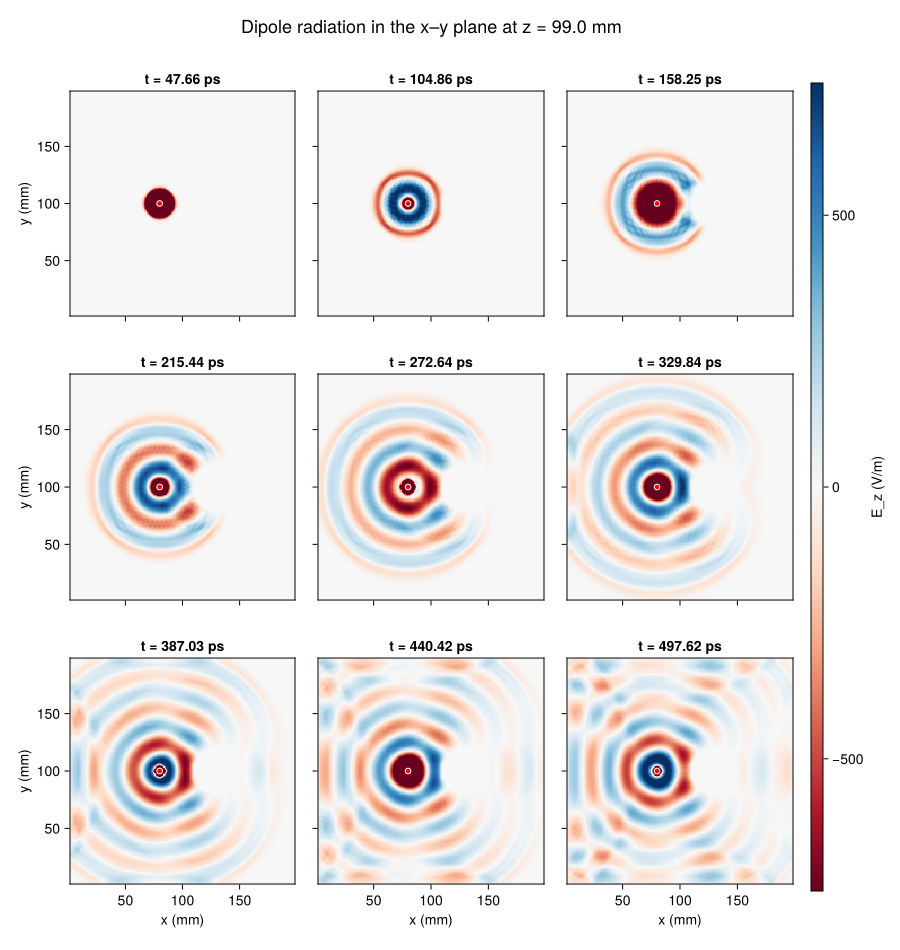

In [7]:
# Sampling grid in mm, one node in from each boundary so the interpolation always
# has a full stencil. MyDomain stores metres, hence the scaling.
mm = 1e-3
xs = LinRange(MyDomain.nodes_u[2]/mm, MyDomain.nodes_u[end-1]/mm, 200)
ys = LinRange(MyDomain.nodes_v[2]/mm, MyDomain.nodes_v[end-1]/mm, 200)

# Interpolate ê onto the cut plane at z_dipole and reduce each triple of field
# components with f — b -> hypot(b...) for the magnitude, last for E_z.
sample_slice(ê, f) =
    [f(FITToolbox.interpolate(MyDomain, PrimalEdge(), ê, x, y, z_dipole; units="mm"))
     for x in xs, y in ys]

# Nine snapshots in a 3×3 grid sharing one colour range, so a brighter panel means
# a stronger field rather than a rescaled axis. Axis labels only on the outer row
# and column, to keep the grid readable.
function snapshot_grid(slices, times, colorrange, colormap, label)
    fig = Figure(size = (900, 950))
    Label(fig[0, 1:3],
          "Dipole radiation in the x–y plane at z = $(round(z_dipole, digits=1)) mm";
          fontsize = 18, padding = (0, 0, 8, 0))

    for (n, slice) in enumerate(slices)
        row, col = fldmod1(n, 3)
        ax = Axis(fig[row, col];
                  title  = "t = $(round(times[n] * 1e12, digits=2)) ps",
                  aspect = DataAspect(),
                  xlabel = row == 3 ? "x (mm)" : "",
                  ylabel = col == 1 ? "y (mm)" : "",
                  xticklabelsvisible = row == 3,
                  yticklabelsvisible = col == 1)

        heatmap!(ax, xs, ys, slice; colormap, colorrange)
        scatter!(ax, [x_dipole], [y_dipole];
                 color = :red, markersize = 8, strokewidth = 1, strokecolor = :white)
    end

    Colorbar(fig[1:3, 4]; colorrange, colormap, label)
    return fig
end


# --- magnitude, logarithmic ---------------------------------------------------
# The floor prevents log10(0) where the field passes through zero.
mag = [log10.(max.(sample_slice(ê, b -> hypot(b...)), 1e-15)) for ê in ê_history]
vmax = maximum(maximum, mag)
fig_mag = snapshot_grid(mag, ê_times, (vmax - 4, vmax), :viridis, "log₁₀(|E|) (V/m)")

# --- z-component, signed ------------------------------------------------------
# The dipole points along z, so E_z carries the sign alternation of the wave. A
# diverging colormap on a symmetric range makes the wavefronts far more legible
# than a magnitude, which is positive everywhere. The 99th percentile rather than
# the maximum keeps the near-field spike from flattening everything else.
ez   = [sample_slice(ê, last) for ê in ê_history]
vabs = quantile(abs.(vcat(vec.(ez)...)), 0.99)
fig_ez = snapshot_grid(ez, ê_times, (-vabs, vabs), :RdBu, "E_z (V/m)")

fig_ez

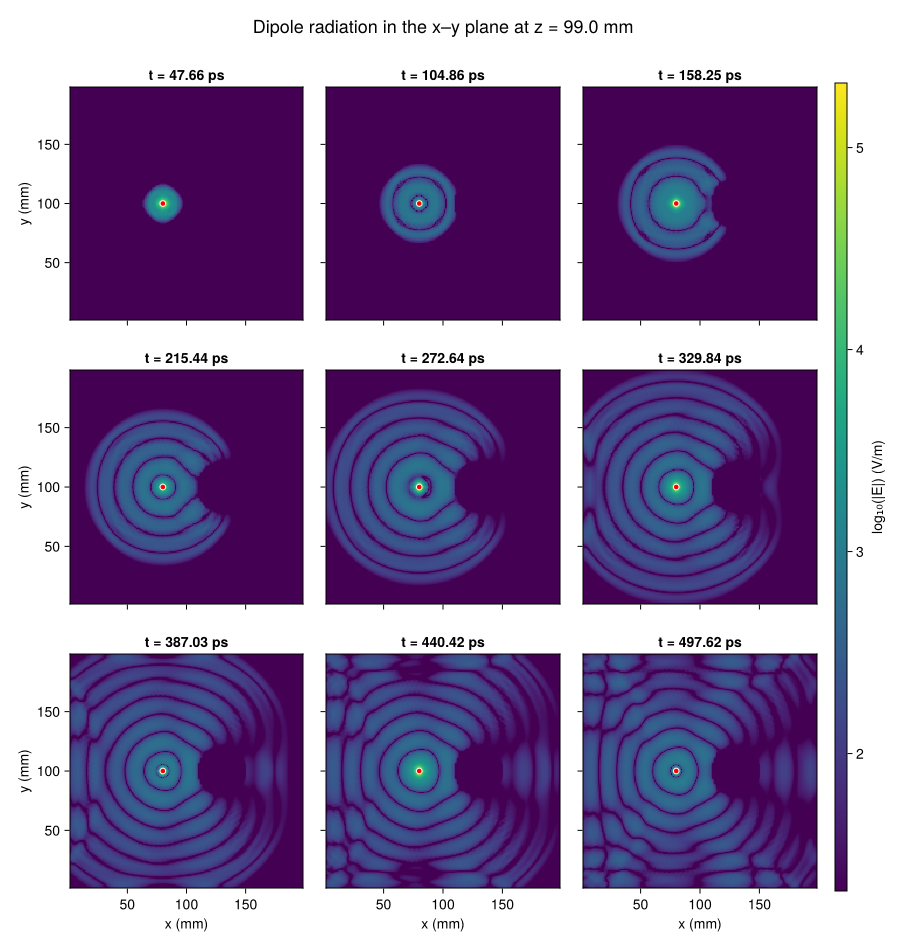

In [8]:
fig_mag